# 개포동 빌라 실거래가 분석

순서 : 데이터 처리 → 피처 엔지니어링 → OLS / 건물 고정효과 모델 → 트렌드 시각화

* 출처 : 국토교통부 실거래가공개시스템 자료제공 (필터: 연립/60제곱미터 이하/개포동)
* 법인 거래 제외 (개인 매도, 개인 매수만 확인)
* 중개거래만 포함 (직거래 제외)

## 0. 설정

In [1]:
import datetime as dt
import polars as pl
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (macOS: AppleGothic, Linux: NanumGothic 등)
import matplotlib
import platform
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')  # 한글 없을 경우 fallback
matplotlib.rc('axes', unicode_minus=False)

# ★ 데이터 경로만 여기서 수정
DATA_PATH = "data.csv"
BASE_YEAR = 2024
BASE_MONTH = 3  # 시간 인덱스 0 기준월
CURRENT_YEAR = dt.datetime.now().year

## 1. 데이터 로드 및 전처리

In [2]:
def load_and_preprocess(path: str) -> pl.DataFrame:
    df = pl.read_csv(path)

    df_med = (
        df.filter(pl.col("거래유형") == "중개거래")
        .with_columns(
            pl.col("거래금액(만원)").str.replace_all(",", "").cast(pl.Int64).alias("price")
        )
        .with_columns(
            (pl.col("본번").cast(pl.Utf8) + "-" + pl.col("부번").cast(pl.Utf8)).alias("building_id")
        )
        .with_columns(
            (
                (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4).cast(pl.Int64) - BASE_YEAR) * 12
                + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2).cast(pl.Int64)
                - BASE_MONTH
            ).alias("time_idx")
        )
        .with_columns(
            (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4) + "-"
             + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2)).alias("ym")
        )
        .with_columns(
            (CURRENT_YEAR - pl.col("건축년도")).alias("age"),
            (pl.col("층") < 0).cast(pl.Int8).alias("is_basement")
        )
        .rename({"전용면적(㎡)": "area", "대지권면적(㎡)": "land_area", "층": "floor"})
        # 개인↔개인 거래만 (법인 대량매입/매각 노이즈 제거)
        .filter((pl.col("매도자") == "개인") & (pl.col("매수자") == "개인"))
    )
    return df_med

df = load_and_preprocess(DATA_PATH)

print(f"전체 → 중개거래 + 개인↔개인: {len(df)}건")
print(f"기간: {df['ym'].min()} ~ {df['ym'].max()}")
print(f"price 중위값: {df['price'].median():,.0f} 만원")
df.select(["building_id","price","area","land_area","floor","age","is_basement","time_idx","ym"]).head(5)

전체 → 중개거래 + 개인↔개인: 238건
기간: 2024-03 ~ 2026-03
price 중위값: 52,500 만원


building_id,price,area,land_area,floor,age,is_basement,time_idx,ym
str,i64,f64,f64,i64,i64,i8,i64,str
"""1168-6""",28300,40.8,19.7,-1,30,1,9,"""2024-12"""
"""1254-5""",78500,54.39,33.7575,3,11,0,9,"""2024-12"""
"""1193-5""",50500,29.95,24.163,6,8,0,9,"""2024-12"""
"""1227-2""",64600,59.99,36.957,5,10,0,9,"""2024-12"""
"""1233-17""",63800,41.58,38.3577,2,40,0,9,"""2024-12"""


## 2. 기초 분포 확인

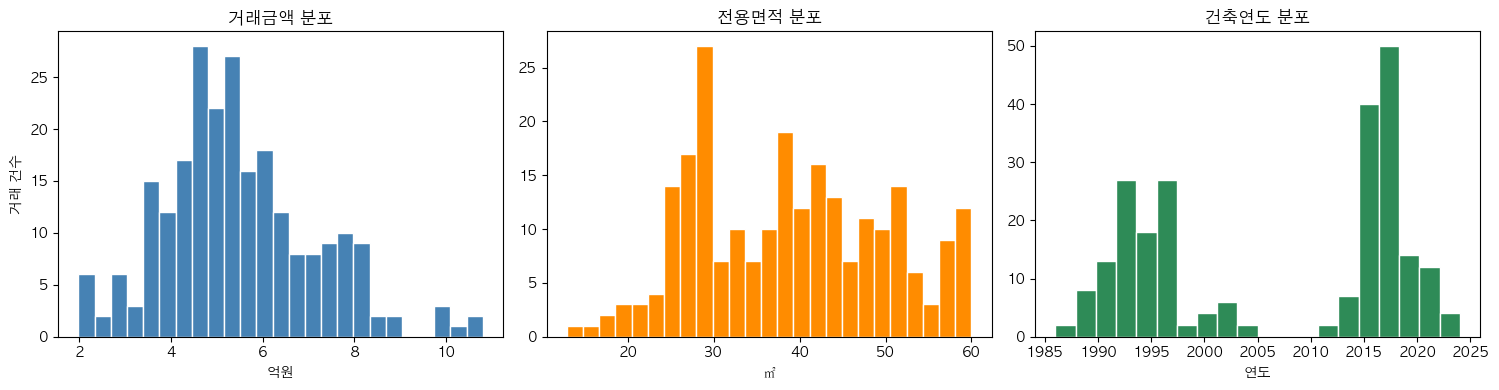

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 거래금액 분포
axes[0].hist(df["price"].to_numpy() / 10000, bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("거래금액 분포")
axes[0].set_xlabel("억원")
axes[0].set_ylabel("거래 건수")

# 전용면적 분포
axes[1].hist(df["area"].to_numpy(), bins=25, color="darkorange", edgecolor="white")
axes[1].set_title("전용면적 분포")
axes[1].set_xlabel("㎡")

# 건축연도 분포
axes[2].hist((CURRENT_YEAR - df["age"]).to_numpy(), bins=20, color="seagreen", edgecolor="white")
axes[2].set_title("건축연도 분포")
axes[2].set_xlabel("연도")

plt.tight_layout()
plt.show()

## 3. 월별 중위 거래가 트렌드

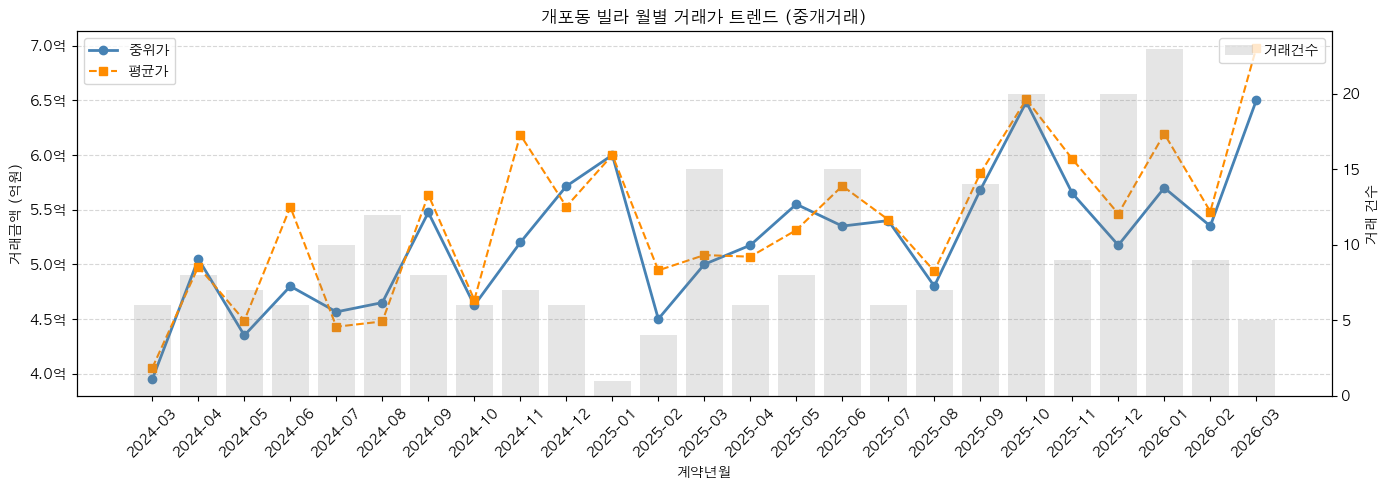

shape: (25, 4)
┌─────────┬──────────────┬──────────────┬─────┐
│ ym      ┆ median_price ┆ mean_price   ┆ n   │
│ ---     ┆ ---          ┆ ---          ┆ --- │
│ str     ┆ f64          ┆ f64          ┆ u32 │
╞═════════╪══════════════╪══════════════╪═════╡
│ 2024-03 ┆ 39500.0      ┆ 40533.333333 ┆ 6   │
│ 2024-04 ┆ 50500.0      ┆ 49787.5      ┆ 8   │
│ 2024-05 ┆ 43500.0      ┆ 44857.142857 ┆ 7   │
│ 2024-06 ┆ 48000.0      ┆ 55250.0      ┆ 6   │
│ 2024-07 ┆ 45650.0      ┆ 44290.0      ┆ 10  │
│ …       ┆ …            ┆ …            ┆ …   │
│ 2025-11 ┆ 56500.0      ┆ 59633.333333 ┆ 9   │
│ 2025-12 ┆ 51750.0      ┆ 54627.5      ┆ 20  │
│ 2026-01 ┆ 57000.0      ┆ 61952.173913 ┆ 23  │
│ 2026-02 ┆ 53500.0      ┆ 54833.333333 ┆ 9   │
│ 2026-03 ┆ 65000.0      ┆ 69800.0      ┆ 5   │
└─────────┴──────────────┴──────────────┴─────┘


In [4]:
monthly = (
    df.group_by("ym").agg([
        pl.col("price").median().alias("median_price"),
        pl.col("price").mean().alias("mean_price"),
        pl.col("price").count().alias("n")
    ]).sort("ym")
)

ym_labels = monthly["ym"].to_list()
med = monthly["median_price"].to_numpy() / 10000
avg = monthly["mean_price"].to_numpy() / 10000
n   = monthly["n"].to_numpy()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(ym_labels, med, marker="o", color="steelblue", linewidth=2, label="중위가")
ax1.plot(ym_labels, avg, marker="s", color="darkorange", linewidth=1.5, linestyle="--", label="평균가")
ax1.set_ylabel("거래금액 (억원)")
ax1.set_xlabel("계약년월")
ax1.set_title("개포동 빌라 월별 거래가 트렌드 (중개거래)")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f억'))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc="upper left")
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 거래 건수 막대
ax2 = ax1.twinx()
ax2.bar(ym_labels, n, alpha=0.2, color="gray", label="거래건수")
ax2.set_ylabel("거래 건수")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(monthly)

## 4. 면적 보정 트렌드 (㎡당 가격)

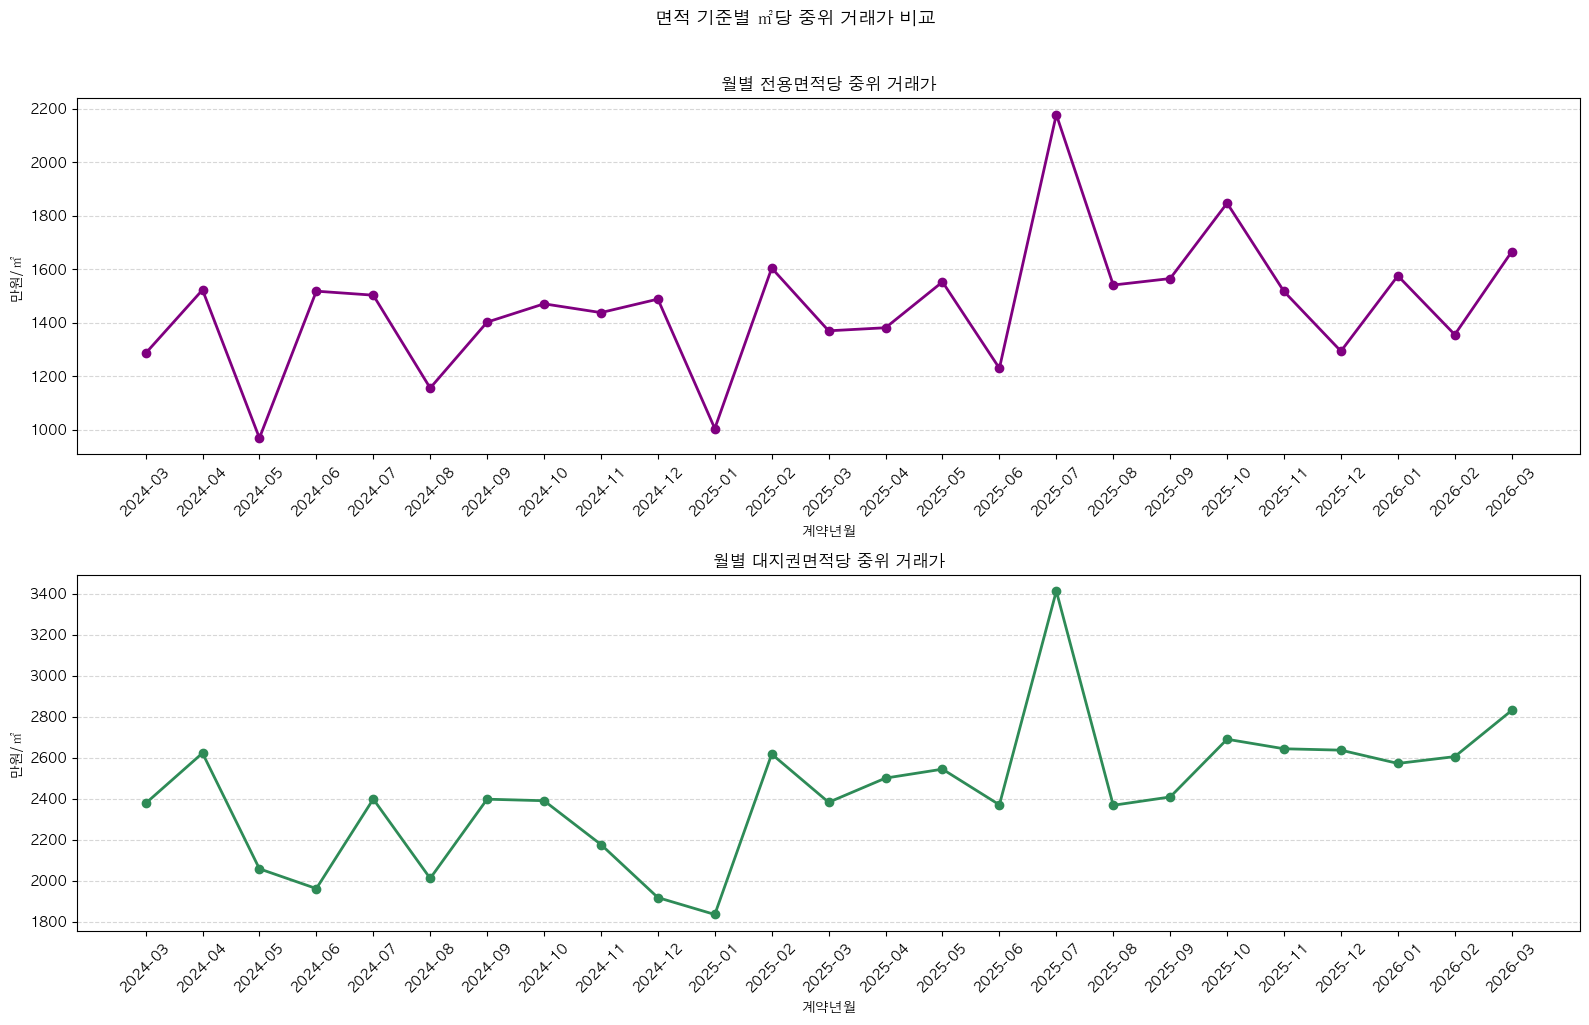

shape: (25, 3)
┌─────────┬─────────────┬─────────────┐
│ ym      ┆ med_area    ┆ med_land    │
│ ---     ┆ ---         ┆ ---         │
│ str     ┆ f64         ┆ f64         │
╞═════════╪═════════════╪═════════════╡
│ 2024-03 ┆ 1286.217612 ┆ 2378.177186 │
│ 2024-04 ┆ 1523.302214 ┆ 2623.544113 │
│ 2024-05 ┆ 969.680415  ┆ 2059.164733 │
│ 2024-06 ┆ 1518.570994 ┆ 1962.896146 │
│ 2024-07 ┆ 1503.536127 ┆ 2399.320232 │
│ …       ┆ …           ┆ …           │
│ 2025-11 ┆ 1517.326225 ┆ 2644.574399 │
│ 2025-12 ┆ 1294.206213 ┆ 2637.871742 │
│ 2026-01 ┆ 1575.854701 ┆ 2573.125137 │
│ 2026-02 ┆ 1356.08049  ┆ 2606.360573 │
│ 2026-03 ┆ 1665.989435 ┆ 2831.491713 │
└─────────┴─────────────┴─────────────┘


In [5]:
df_ppm = df.with_columns([
    (pl.col("price") / pl.col("area")).alias("price_per_area"),
    (pl.col("price") / pl.col("land_area")).alias("price_per_land")
])

monthly_ppm = (
    df_ppm.group_by("ym").agg([
        pl.col("price_per_area").median().alias("med_area"),
        pl.col("price_per_land").median().alias("med_land")
    ]).sort("ym")
)

ym_list = monthly_ppm["ym"].to_list()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharey=False)

axes[0].plot(ym_list, monthly_ppm["med_area"].to_numpy(),
             marker="o", color="purple", linewidth=2)
axes[0].set_title("월별 전용면적당 중위 거래가")
axes[0].set_ylabel("만원/㎡")
axes[0].set_xlabel("계약년월")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].plot(ym_list, monthly_ppm["med_land"].to_numpy(),
             marker="o", color="seagreen", linewidth=2)
axes[1].set_title("월별 대지권면적당 중위 거래가")
axes[1].set_ylabel("만원/㎡")
axes[1].set_xlabel("계약년월")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("면적 기준별 ㎡당 중위 거래가 비교", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(monthly_ppm)

## 5. 모델 1: 기본 OLS

In [6]:
df_pd = df.select(["price","area","land_area","floor","age","is_basement","time_idx","building_id"]).to_pandas()

m1 = smf.ols("price ~ area + land_area + floor + age + is_basement + time_idx", data=df_pd).fit()

print(f"=== 모델 1: 기본 OLS (n={len(df_pd)}) ===")
print(f"R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
print()

summary = pl.DataFrame({
    "변수": m1.params.index.tolist(),
    "계수": m1.params.values.round(1).tolist(),
    "p-value": m1.pvalues.values.round(4).tolist(),
    "유의": ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "" for p in m1.pvalues.values]
})
print(summary)

print(f"""
해석:
  전용면적 +1㎡  → 가격 +{m1.params['area']:,.0f} 만원
  건축연도 +1년  → 가격 {m1.params['age']:,.0f} 만원
  지하층         → 가격 {m1.params['is_basement']:,.0f} 만원
  월 추세        → 가격 +{m1.params['time_idx']:,.0f} 만원/월
""")

=== 모델 1: 기본 OLS (n=238) ===
R²=0.6178  Adj R²=0.6079

shape: (7, 4)
┌─────────────┬──────────┬─────────┬──────┐
│ 변수        ┆ 계수     ┆ p-value ┆ 유의 │
│ ---         ┆ ---      ┆ ---     ┆ ---  │
│ str         ┆ f64      ┆ f64     ┆ str  │
╞═════════════╪══════════╪═════════╪══════╡
│ Intercept   ┆ 23118.4  ┆ 0.0     ┆ ***  │
│ area        ┆ 805.8    ┆ 0.0     ┆ ***  │
│ land_area   ┆ 245.3    ┆ 0.0001  ┆ ***  │
│ floor       ┆ -130.7   ┆ 0.8164  ┆      │
│ age         ┆ -598.7   ┆ 0.0     ┆ ***  │
│ is_basement ┆ -15461.6 ┆ 0.0     ┆ ***  │
│ time_idx    ┆ 576.9    ┆ 0.0     ┆ ***  │
└─────────────┴──────────┴─────────┴──────┘

해석:
  전용면적 +1㎡  → 가격 +806 만원
  건축연도 +1년  → 가격 -599 만원
  지하층         → 가격 -15,462 만원
  월 추세        → 가격 +577 만원/월



## 6. 모델 2: 건물 고정효과 (반복거래 5회 이상)

In [7]:
freq = df_pd["building_id"].value_counts()
buildings_5plus = freq[freq >= 5].index.tolist()
df_fe = df_pd[df_pd["building_id"].isin(buildings_5plus)].copy()

m2 = smf.ols("price ~ area + land_area + floor + age + is_basement + time_idx + C(building_id)", data=df_fe).fit()

coef_t = m2.params["time_idx"]
pval_t = m2.pvalues["time_idx"]
median_p = df_pd["price"].median()

print(f"=== 모델 2: 건물 고정효과 (n={len(df_fe)}) ===")
print(f"R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")
print(f"""
time_idx 계수 : {coef_t:,.0f} 만원/월
p-value       : {pval_t:.4f}
월 상승률     : {coef_t/median_p*100:.2f}%
연환산 상승률 : {((1 + coef_t/median_p)**12 - 1)*100:.1f}%
""")

=== 모델 2: 건물 고정효과 (n=41) ===
R²=0.9215  Adj R²=0.8953

time_idx 계수 : 593 만원/월
p-value       : 0.0000
월 상승률     : 1.13%
연환산 상승률 : 14.4%



## 7. 모델 적합값 vs 실제값 시각화

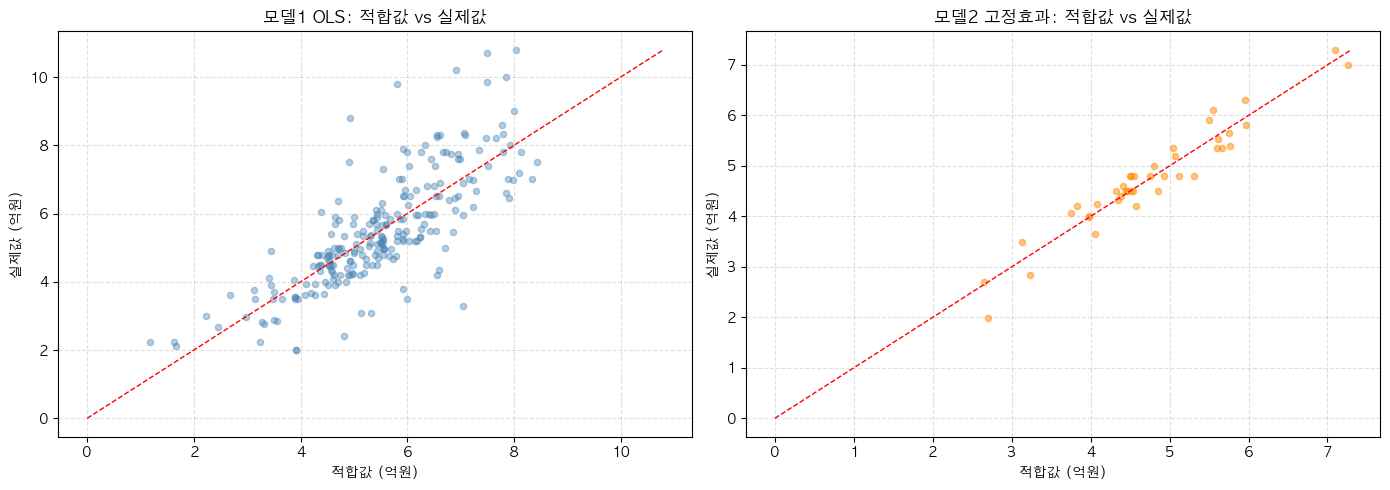

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 모델 1 잔차
fitted1 = m1.fittedvalues
actual1 = df_pd["price"]
axes[0].scatter(fitted1 / 10000, actual1 / 10000, alpha=0.4, color="steelblue", s=20)
lim = max(fitted1.max(), actual1.max()) / 10000
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_title("모델1 OLS: 적합값 vs 실제값")
axes[0].set_xlabel("적합값 (억원)")
axes[0].set_ylabel("실제값 (억원)")
axes[0].grid(linestyle='--', alpha=0.4)

# 모델 2 잔차
fitted2 = m2.fittedvalues
actual2 = df_fe["price"]
axes[1].scatter(fitted2 / 10000, actual2 / 10000, alpha=0.5, color="darkorange", s=20)
lim2 = max(fitted2.max(), actual2.max()) / 10000
axes[1].plot([0, lim2], [0, lim2], "r--", linewidth=1)
axes[1].set_title("모델2 고정효과: 적합값 vs 실제값")
axes[1].set_xlabel("적합값 (억원)")
axes[1].set_ylabel("실제값 (억원)")
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 8. 시간 추세 회귀선 오버레이

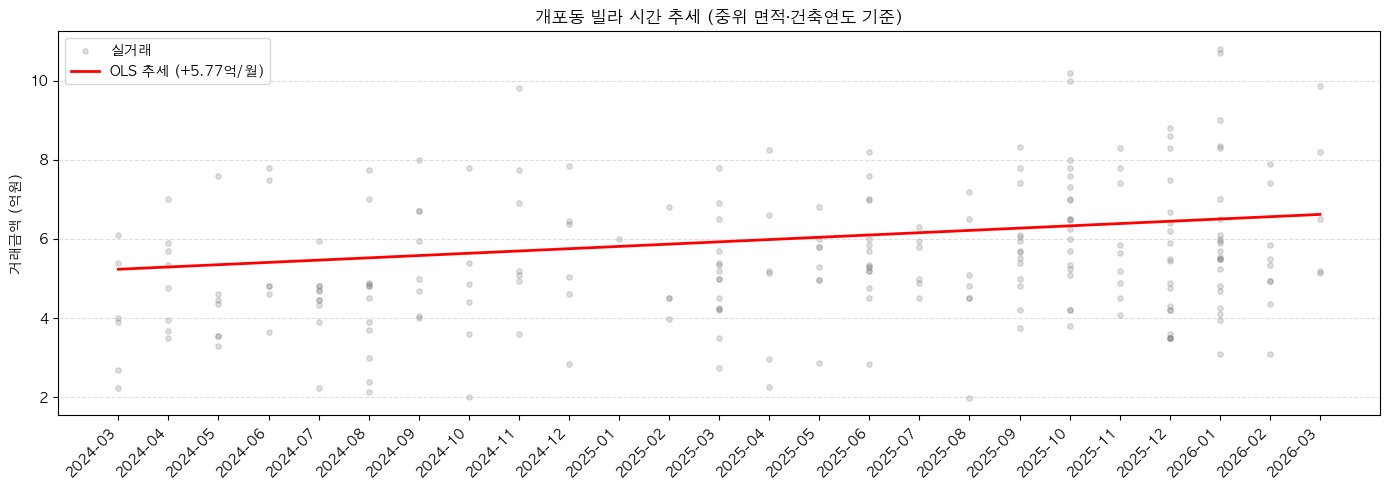

In [9]:
# OLS 모델의 time_idx 추세를 중위 면적 기준으로 시각화
med_area = df_pd["area"].median()
med_land = df_pd["land_area"].median()
med_floor = df_pd["floor"].median()
med_age = df_pd["age"].median()

t_range = np.arange(df_pd["time_idx"].min(), df_pd["time_idx"].max() + 1)
pred_price = (
    m1.params["Intercept"]
    + m1.params["area"] * med_area
    + m1.params["land_area"] * med_land
    + m1.params["floor"] * med_floor
    + m1.params["age"] * med_age
    + m1.params["is_basement"] * 0
    + m1.params["time_idx"] * t_range
)

# ym 라벨 매핑
ym_map = df.select(["time_idx","ym"]).unique().sort("time_idx").to_pandas()
ym_map = dict(zip(ym_map["time_idx"], ym_map["ym"]))
t_labels = [ym_map.get(t, str(t)) for t in t_range]

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_pd["time_idx"], df_pd["price"] / 10000, alpha=0.25, color="gray", s=15, label="실거래")
ax.plot(t_range, pred_price / 10000, color="red", linewidth=2, label=f"OLS 추세 (+{m1.params['time_idx']/10000*100:.2f}억/월)")
ax.set_xticks(t_range)
ax.set_xticklabels(t_labels, rotation=45, ha='right')
ax.set_title("개포동 빌라 시간 추세 (중위 면적·건축연도 기준)")
ax.set_ylabel("거래금액 (억원)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()